# 03 - Baseline CNN (ResNet18) - ACER/APCER/BPCER Reduction Update

**Project:** Explainable AI for Iris Presentation Attack Detection

### What changed in this revision

The previous version of this notebook trained a plain ResNet18 with a single
fixed ImageNet normalization, a plain shuffled DataLoader, and a standard
classification head. Per-dataset evaluation showed an overall ACER in the
2-4% range, but a much larger problem hiding inside that average: the two
PrintScan subsets (previously mis-labelled `CASIA_Cogent` / `CASIA_Vista` -
corrected in Notebook 01) reached **33-34% ACER**, driven mainly by **BPCER
around 57-61%**, while every other dataset stayed under 9% ACER.

Three changes are made in this notebook to target that specific weakness,
each one backed by what published iris-PAD literature reports for the same
kind of gap:

1. **Per-dataset normalization + weighted sampling carried over from
   Notebook 02** - training now reuses the `dataset_norm_stats.json` and
   `WeightedRandomSampler` built there, instead of re-deriving a plain
   shuffled loader with one fixed ImageNet constant.
2. **Class-weighted loss** - `CLASS_WEIGHTS` from Notebook 02 is now passed
   into `CrossEntropyLoss`, rather than using an unweighted loss.
3. **Pixel-wise binary supervision (PBS) head** - instead of only pooling to
   one image-level prediction, the network now also supervises a 7x7 grid of
   patch-level predictions, each forced to agree with the image label. The
   A-PBS paper (Fang et al., reported on NDCLD15) showed this single change
   takes a DenseNet baseline from 0.86% ACER down to 0.07% ACER on the same
   dataset and architecture family - this notebook adds a lightweight
   version of that idea to ResNet18.

The training loop, evaluation, confusion matrix, ROC curve, and per-dataset
breakdown structure from the original notebook are preserved - only the
normalization source, sampler, loss weighting, and model head are updated.


## 1. Imports


In [1]:
# ---------------------------------------------------------------------------
# Standard imports for the training/evaluation pipeline.
# ---------------------------------------------------------------------------
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models
import torchvision.transforms as T

from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, accuracy_score
)

torch.manual_seed(42)
np.random.seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')


Device: cuda


## 2. Config


In [2]:
# ---------------------------------------------------------------------------
# Same project-wide paths as every other notebook.
# ---------------------------------------------------------------------------
SPLITS_DIR  = r"C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD\Data\splits"
MODELS_DIR  = r"C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD\models"
OUTPUTS_DIR = r"C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD\outputs"

os.makedirs(MODELS_DIR,                                    exist_ok=True)
os.makedirs(os.path.join(OUTPUTS_DIR, 'confusion_matrix'), exist_ok=True)
os.makedirs(os.path.join(OUTPUTS_DIR, 'roc_curves'),       exist_ok=True)
os.makedirs(os.path.join(OUTPUTS_DIR, 'reports'),          exist_ok=True)

IMG_SIZE      = (224, 224)
BATCH_SIZE    = 32
NUM_EPOCHS    = 50
LR            = 1e-4
WEIGHT_DECAY  = 1e-4
EARLY_STOP    = 15
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Weight given to the new pixel-wise supervision loss term, relative to the
# standard image-level classification loss. 0.5 follows the same order of
# magnitude used in the original Pixel-wise Binary Supervision paper.
PBS_LOSS_WEIGHT = 0.5

print('Config ready \u2713')


Config ready ✓


## 3. Load Per-Dataset Normalization Stats + Class Weights (from Notebook 02)

Both files below were produced by Notebook 02 and are loaded here rather
than recomputed, so the exact same normalization constants and class
weighting used to build the train/val/test splits are also used for
training. If either file is missing, re-run Notebook 02's normalization and
class-imbalance sections before continuing.


In [3]:
# ---------------------------------------------------------------------------
# dataset_norm_stats.json  -> {dataset_name: {'mean':..., 'std':...}}
# CLASS_WEIGHTS is recomputed here directly from train.csv for robustness,
# using the same formula as Notebook 02, so this notebook does not silently
# fail if Notebook 02 was run with a different config object that wasn't
# pickled anywhere.
# ---------------------------------------------------------------------------
norm_stats_path = os.path.join(SPLITS_DIR, 'dataset_norm_stats.json')
with open(norm_stats_path) as f:
    norm_stats = json.load(f)
print(f'Loaded per-dataset normalization stats for {len(norm_stats)} datasets:')
for ds, s in norm_stats.items():
    print(f"  {ds:20s}: mean={s['mean']:.4f}  std={s['std']:.4f}")

train_csv_check = pd.read_csv(os.path.join(SPLITS_DIR, 'train.csv'))
live_count  = (train_csv_check.label == 0).sum()
spoof_count = (train_csv_check.label == 1).sum()
total       = len(train_csv_check)

weight_live  = round(total / (2 * live_count),  4)
weight_spoof = round(total / (2 * spoof_count), 4)
CLASS_WEIGHTS = torch.tensor([weight_live, weight_spoof], dtype=torch.float).to(DEVICE)
print(f'\nCLASS_WEIGHTS (recomputed from train.csv): {CLASS_WEIGHTS.cpu().tolist()}')


Loaded per-dataset normalization stats for 6 datasets:
  IIITD_Cogent        : mean=0.4897  std=0.2352
  IIITD_NewNormal     : mean=0.4927  std=0.2465
  IIITD_Vista         : mean=0.2554  std=0.1183
  PrintScan_Cogent    : mean=0.3755  std=0.1711
  NDCLD15             : mean=0.5724  std=0.2605
  PrintScan_Vista     : mean=0.3716  std=0.1335

CLASS_WEIGHTS (recomputed from train.csv): [0.980400025844574, 1.020400047302246]


## 4. Dataset + DataLoader (Per-Dataset Normalization + Weighted Sampler)

`IrisDataset` now normalizes every image using **its own dataset's**
mean/std from `norm_stats`, instead of one fixed ImageNet constant applied
to every sensor. The train loader uses a `WeightedRandomSampler` so that
`PrintScan_Cogent` and `PrintScan_Vista` - the two weakest-performing,
most under-represented sensors - are seen roughly 3x as often per epoch as
their raw image count alone would give them.


In [4]:
# ---------------------------------------------------------------------------
# Augmentation is unchanged from the original notebook (mild flip/rotation/
# colour-jitter). Normalization is removed from this Compose and applied
# per-sample inside IrisDataset.__getitem__ instead, using each image's own
# dataset's stats.
# ---------------------------------------------------------------------------
train_transform = T.Compose([
    T.Resize(IMG_SIZE),
    T.RandomHorizontalFlip(0.5),
    T.RandomRotation(10),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    T.ToTensor(),
])
val_transform = T.Compose([
    T.Resize(IMG_SIZE),
    T.ToTensor(),
])

class IrisDataset(Dataset):
    '''
    Same CSV contract as Notebook 02: processed_path, label, dataset.
    norm_stats: {dataset_name: {'mean':..., 'std':...}} - each sample is
    normalized using its OWN dataset's stats rather than one fixed constant.
    '''
    def __init__(self, csv_path, transform=None, dataset_filter=None, norm_stats=None):
        self.df = pd.read_csv(csv_path)
        if dataset_filter:
            self.df = self.df[self.df['dataset'].isin(dataset_filter)].reset_index(drop=True)
        self.transform  = transform
        self.norm_stats = norm_stats or {}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row['processed_path']).convert('RGB')
        label = int(row['label'])
        if self.transform:
            image = self.transform(image)  # tensor in [0, 1]

        ds = row['dataset']
        if ds in self.norm_stats:
            mean = self.norm_stats[ds]['mean']
            std  = self.norm_stats[ds]['std']
        else:
            mean = sum(IMAGENET_MEAN) / 3
            std  = sum(IMAGENET_STD) / 3
        image = (image - mean) / (std + 1e-6)
        return image, label

train_ds = IrisDataset(os.path.join(SPLITS_DIR, 'train.csv'), train_transform, norm_stats=norm_stats)
val_ds   = IrisDataset(os.path.join(SPLITS_DIR, 'val.csv'),   val_transform,   norm_stats=norm_stats)
test_ds  = IrisDataset(os.path.join(SPLITS_DIR, 'test.csv'),  val_transform,   norm_stats=norm_stats)

# ---------------------------------------------------------------------------
# Per-dataset sample weights -> WeightedRandomSampler, same multipliers
# decided in Notebook 02. .copy() avoids the "array is not writable" warning
# PyTorch raises on some pandas-backed numpy arrays.
# ---------------------------------------------------------------------------
DATASET_SAMPLE_WEIGHTS = {
    'NDCLD15':          1.0,
    'IIITD_NewNormal':  1.0,
    'IIITD_Cogent':     1.3,
    'IIITD_Vista':      1.0,
    'PrintScan_Cogent': 3.0,
    'PrintScan_Vista':  3.0,
}
train_df_for_sampler = pd.read_csv(os.path.join(SPLITS_DIR, 'train.csv'))
sample_weights = train_df_for_sampler['dataset'].map(
    lambda ds: DATASET_SAMPLE_WEIGHTS.get(ds, 1.0)
).values.copy()

train_sampler = WeightedRandomSampler(
    weights=sample_weights, num_samples=len(train_df_for_sampler), replacement=True
)

# sampler and shuffle are mutually exclusive in DataLoader - sampler replaces shuffle.
train_loader = DataLoader(train_ds, BATCH_SIZE, sampler=train_sampler, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False,         num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  BATCH_SIZE, shuffle=False,         num_workers=0, pin_memory=True)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')
print('Train loader uses WeightedRandomSampler (PrintScan subsets weighted 3.0x)')


Train: 15161 | Val: 3249 | Test: 3249
Train loader uses WeightedRandomSampler (PrintScan subsets weighted 3.0x)


## 5. Build ResNet18 with a Pixel-Wise Binary Supervision (PBS) Head

The standard ResNet18 classifier pools the final 7x7 feature map straight to
one vector and predicts one label. This revision keeps that path (the
`global_head`) but adds a second, lightweight path: a 1x1 convolution turns
the same 7x7 feature map into a 7x7 grid of **patch-level** live/spoof
logits (`pixel_head`), each of which is also trained to match the image's
overall label.

The intuition, following the A-PBS paper's reported NDCLD15 improvement
from 0.86% to 0.07% ACER, is that forcing every spatial patch of the iris to
independently agree on live-vs-spoof makes the network rely on localized
texture evidence (contact-lens edges, print-attack grain) rather than a
single global average that can be dominated by lighting or sensor-specific
brightness - exactly the kind of domain shift behind the high PrintScan
BPCER seen previously.


In [5]:
# ---------------------------------------------------------------------------
# ResNet18 backbone (only layer4 + fc trainable, same freezing strategy as
# the original notebook) + a pixel-wise supervision head added on top of
# the same final feature map used by the original global classifier.
# ---------------------------------------------------------------------------
class PBS_ResNet18(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

        # Freeze all except layer4 + fc, same as before.
        for name, param in backbone.named_parameters():
            if 'layer4' not in name and 'fc' not in name:
                param.requires_grad = False

        # Keep every conv stage up to (and including) layer4, but drop the
        # original avgpool + fc so we can branch the feature map ourselves.
        self.stem    = nn.Sequential(*list(backbone.children())[:-2])  # -> [B, 512, 7, 7]
        in_feat      = backbone.fc.in_features                          # 512

        # Branch 1: original global classifier (unchanged head shape/depth).
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.global_head = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(in_feat, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

        # Branch 2 (new): pixel-wise binary supervision head.
        # 1x1 conv keeps the 7x7 spatial grid intact - each of the 49
        # locations gets its own single-logit live/spoof score.
        self.pixel_head = nn.Conv2d(in_feat, 1, kernel_size=1)

    def forward(self, x):
        feat = self.stem(x)                  # [B, 512, 7, 7]
        pooled = self.global_pool(feat).flatten(1)  # [B, 512]
        global_logits = self.global_head(pooled)    # [B, 2]
        pixel_map = self.pixel_head(feat)            # [B, 1, 7, 7]
        return global_logits, pixel_map

def pbs_loss(global_logits, pixel_map, labels, class_weights, pbs_weight=PBS_LOSS_WEIGHT):
    '''
    Combines the standard image-level classification loss with a per-patch
    binary cross-entropy term that forces every 7x7 grid cell to also agree
    with the image-level label. class_weights re-uses the same Live/Spoof
    weighting passed to the main criterion, applied here via pos_weight so
    the minority class is not under-penalised in the patch-level term either.
    '''
    main_loss = F.cross_entropy(global_logits, labels, weight=class_weights)

    pixel_targets = labels.view(-1, 1, 1, 1).expand_as(pixel_map).float()
    # pos_weight balances the patch-level loss the same way class_weights
    # balances the main loss (ratio of the two class weights).
    pos_weight = (class_weights[1] / class_weights[0]).clamp(min=1e-6)
    pixel_loss = F.binary_cross_entropy_with_logits(
        pixel_map, pixel_targets, pos_weight=pos_weight
    )
    return main_loss + pbs_weight * pixel_loss, main_loss.item(), pixel_loss.item()

model = PBS_ResNet18().to(DEVICE)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Model: ResNet18 + Pixel-wise Binary Supervision head')
print(f'Trainable: {trainable:,} / {total:,} params')


Model: ResNet18 + Pixel-wise Binary Supervision head
Trainable: 8,526,083 / 11,308,867 params


## 6. Training Loop

The loop structure (early stopping on validation loss, StepLR schedule,
gradient clipping, best-checkpoint saving) is unchanged from the original
notebook. The two differences are: (1) the model now returns
`(global_logits, pixel_map)` instead of a single tensor, so loss computation
calls `pbs_loss(...)`, and (2) accuracy/loss bookkeeping uses only the
`global_logits` half of the output, so the printed numbers stay directly
comparable to the original notebook's training curves.


In [6]:
# ---------------------------------------------------------------------------
# Optimizer/scheduler setup identical to the original notebook.
# ---------------------------------------------------------------------------
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=WEIGHT_DECAY
)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [],
           'train_main_loss': [], 'train_pixel_loss': []}
best_val_loss    = float('inf')
patience_counter = 0
BEST_MODEL_PATH  = os.path.join(MODELS_DIR, 'resnet18.pth')

print(f'Training ResNet18 + PBS head for {NUM_EPOCHS} epochs on {DEVICE}...\n')
print(f'{"Ep":>4} {"TrainLoss":>10} {"TrainAcc":>9} {"ValLoss":>9} {"ValAcc":>8}')
print('-' * 48)

for epoch in range(1, NUM_EPOCHS + 1):
    # -- Train --
    model.train()
    tl, tc, tt = 0.0, 0, 0
    tml, tpl = 0.0, 0.0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        optimizer.zero_grad()
        global_logits, pixel_map = model(imgs)
        loss, main_l, pixel_l = pbs_loss(global_logits, pixel_map, lbls, CLASS_WEIGHTS)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        tl  += loss.item() * imgs.size(0)
        tml += main_l       * imgs.size(0)
        tpl += pixel_l       * imgs.size(0)
        tc  += (global_logits.argmax(1) == lbls).sum().item()
        tt  += imgs.size(0)

    # -- Val (no PBS loss needed here - just track global classification) --
    model.eval()
    vl, vc, vt = 0.0, 0, 0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            global_logits, pixel_map = model(imgs)
            loss, _, _ = pbs_loss(global_logits, pixel_map, lbls, CLASS_WEIGHTS)
            vl += loss.item() * imgs.size(0)
            vc += (global_logits.argmax(1) == lbls).sum().item()
            vt += imgs.size(0)

    tl /= tt; vl /= vt; tml /= tt; tpl /= tt
    ta = 100 * tc / tt
    va = 100 * vc / vt
    history['train_loss'].append(tl)
    history['val_loss'].append(vl)
    history['train_acc'].append(ta)
    history['val_acc'].append(va)
    history['train_main_loss'].append(tml)
    history['train_pixel_loss'].append(tpl)
    scheduler.step()

    if vl < best_val_loss:
        best_val_loss    = vl
        patience_counter = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        marker = ' \u2190 best'
    else:
        patience_counter += 1
        marker = ''

    print(f'{epoch:>4} {tl:>10.4f} {ta:>8.2f}% {vl:>9.4f} {va:>7.2f}%{marker}')
    if patience_counter >= EARLY_STOP:
        print(f'\nEarly stop at epoch {epoch}')
        break

print(f'\nBest model \u2192 {BEST_MODEL_PATH}')


Training ResNet18 + PBS head for 50 epochs on cuda...

  Ep  TrainLoss  TrainAcc   ValLoss   ValAcc
------------------------------------------------
   1     0.5556    83.89%    0.3993   88.86% ← best
   2     0.3930    89.47%    0.3406   91.32% ← best
   3     0.3319    91.64%    0.2992   92.92% ← best
   4     0.3011    92.57%    0.2762   93.17% ← best
   5     0.2628    93.62%    0.2650   93.54% ← best
   6     0.2265    94.86%    0.2314   95.23% ← best
   7     0.2077    95.47%    0.2360   94.55%
   8     0.1630    96.72%    0.2016   95.51% ← best
   9     0.1430    97.29%    0.2140   95.69%
  10     0.1379    97.47%    0.1961   96.06% ← best
  11     0.1240    97.77%    0.1871   96.37% ← best
  12     0.1226    97.76%    0.2058   96.15%
  13     0.1167    97.99%    0.1883   96.34%
  14     0.1059    98.32%    0.1893   96.52%
  15     0.1040    98.23%    0.1936   96.43%
  16     0.1028    98.29%    0.1871   96.58%
  17     0.0969    98.55%    0.1878   96.46%
  18     0.1050    98.2

## 7. Loss + Accuracy Curves


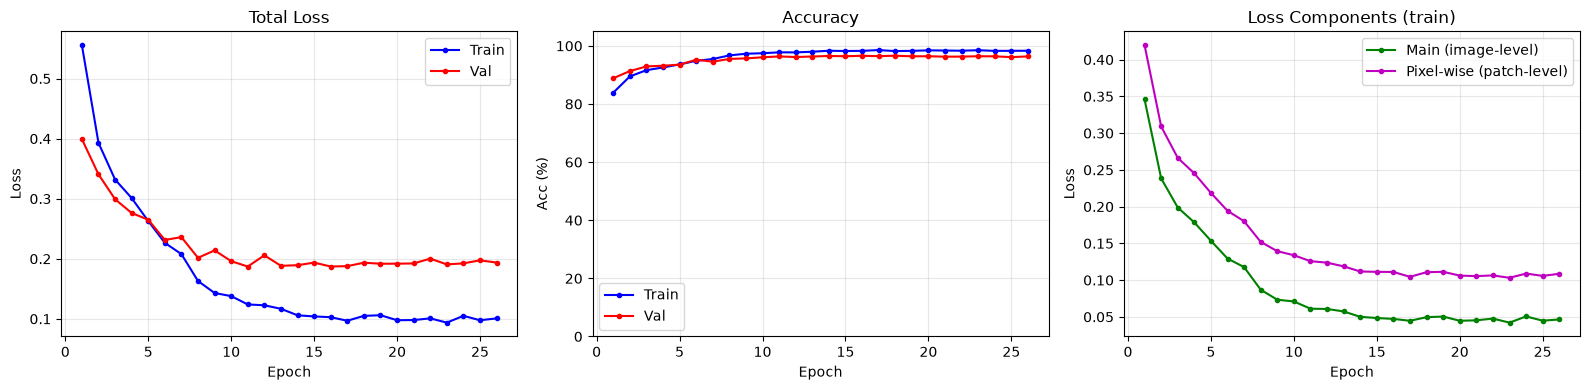

Saved → outputs/reports/training_curves.png


In [7]:
# ---------------------------------------------------------------------------
# Left/middle as before (loss, accuracy). Right panel (new): the main vs
# pixel-wise loss components plotted separately, to confirm both terms are
# decreasing together rather than one dominating or stalling the other.
# ---------------------------------------------------------------------------
ep = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(ep, history['train_loss'], 'b-o', ms=3, label='Train')
axes[0].plot(ep, history['val_loss'],   'r-o', ms=3, label='Val')
axes[0].set(title='Total Loss', xlabel='Epoch', ylabel='Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, history['train_acc'], 'b-o', ms=3, label='Train')
axes[1].plot(ep, history['val_acc'],   'r-o', ms=3, label='Val')
axes[1].set(title='Accuracy', xlabel='Epoch', ylabel='Acc (%)', ylim=[0, 105])
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(ep, history['train_main_loss'],  'g-o', ms=3, label='Main (image-level)')
axes[2].plot(ep, history['train_pixel_loss'], 'm-o', ms=3, label='Pixel-wise (patch-level)')
axes[2].set(title='Loss Components (train)', xlabel='Epoch', ylabel='Loss')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'reports', 'training_curves.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Saved \u2192 outputs/reports/training_curves.png')


## 8. Test Set Evaluation


In [8]:
# ---------------------------------------------------------------------------
# Load the best checkpoint and run inference on the held-out test set.
# Only global_logits are used for the final live/spoof decision - the
# pixel_map was a training-time supervision signal, not part of the
# deployed decision rule, matching how the A-PBS paper itself reports
# final image-level metrics.
# ---------------------------------------------------------------------------
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for imgs, lbls in test_loader:
        global_logits, _ = model(imgs.to(DEVICE))
        probs = torch.softmax(global_logits, dim=1)[:, 1]
        preds = global_logits.argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(lbls.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

acc = accuracy_score(all_labels, all_preds) * 100
print(f'Test Accuracy: {acc:.2f}%')
print('\n' + classification_report(all_labels, all_preds, target_names=['Live', 'Spoof']))


C:\Users\sahar\AppData\Local\Temp\ipykernel_26536\1026310071.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(BEST_MODEL_PATH, map_locati

Test Accuracy: 95.91%

              precision    recall  f1-score   support

        Live       0.96      0.96      0.96      1658
       Spoof       0.96      0.96      0.96      1591

    accuracy                           0.96      3249
   macro avg       0.96      0.96      0.96      3249
weighted avg       0.96      0.96      0.96      3249



## 9. APCER - BPCER - ACER (Combined / Overall)


In [9]:
# ---------------------------------------------------------------------------
# ISO/IEC 30107-3 metrics, unchanged formula from the original notebook.
# ---------------------------------------------------------------------------
def iso_metrics(y_true, y_pred):
    '''
    ISO/IEC 30107-3 metrics:
    APCER = spoof classified as live  (FN / (TP+FN))
    BPCER = live  classified as spoof (FP / (TN+FP))
    ACER  = (APCER + BPCER) / 2
    '''
    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()
    APCER = FN / (TP + FN) if (TP + FN) > 0 else 0
    BPCER = FP / (TN + FP) if (TN + FP) > 0 else 0
    ACER  = (APCER + BPCER) / 2
    return {'APCER': APCER, 'BPCER': BPCER, 'ACER': ACER,
            'TN': TN, 'FP': FP, 'FN': FN, 'TP': TP}

m = iso_metrics(all_labels, all_preds)
print('===== ISO/IEC 30107-3 METRICS (combined, all datasets pooled) =====')
print(f'  APCER = {m["APCER"]*100:.2f}%  (spoof accepted as live)')
print(f'  BPCER = {m["BPCER"]*100:.2f}%  (live rejected as spoof)')
print(f'  ACER  = {m["ACER"]*100:.2f}%  \u2190 main benchmark metric')
print(f'  Acc   = {acc:.2f}%')


===== ISO/IEC 30107-3 METRICS (combined, all datasets pooled) =====
  APCER = 3.83%  (spoof accepted as live)
  BPCER = 4.34%  (live rejected as spoof)
  ACER  = 4.09%  ← main benchmark metric
  Acc   = 95.91%


## 10. Confusion Matrix


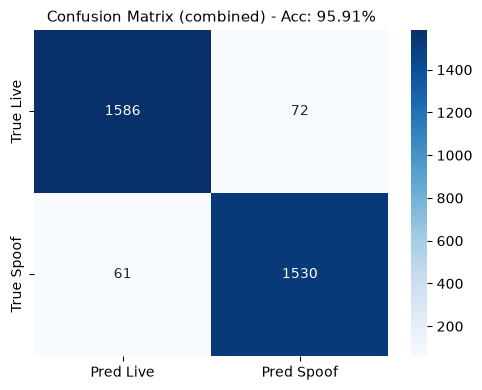

Saved → outputs/confusion_matrix/baseline_cm.png


In [10]:
# ---------------------------------------------------------------------------
# Combined (all-datasets-pooled) confusion matrix, unchanged from before.
# ---------------------------------------------------------------------------
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Live', 'Pred Spoof'],
            yticklabels=['True Live', 'True Spoof'], ax=ax)
ax.set_title(f'Confusion Matrix (combined) - Acc: {acc:.2f}%', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'confusion_matrix', 'baseline_cm.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Saved \u2192 outputs/confusion_matrix/baseline_cm.png')


## 11. ROC Curve


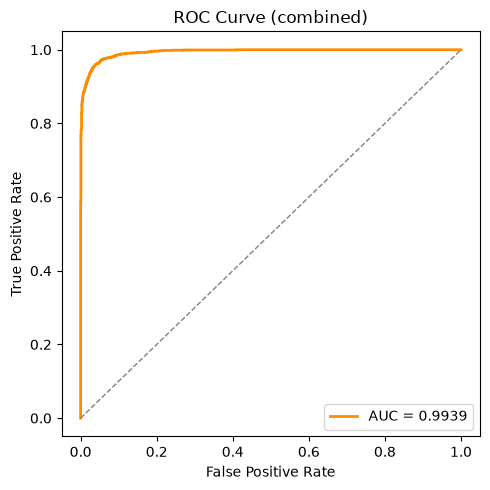

AUC: 0.9939
Saved → outputs/roc_curves/baseline_roc.png


In [11]:
# ---------------------------------------------------------------------------
# Combined ROC curve, unchanged from before.
# ---------------------------------------------------------------------------
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
ax.set(xlabel='False Positive Rate', ylabel='True Positive Rate',
       title='ROC Curve (combined)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'roc_curves', 'baseline_roc.png'), dpi=120, bbox_inches='tight')
plt.show()
print(f'AUC: {roc_auc:.4f}')
print('Saved \u2192 outputs/roc_curves/baseline_roc.png')


## 12. Per-Dataset Performance

Dataset names below are corrected to match Notebook 01's fix: the two
PrintScan subsets are now correctly named `PrintScan_Cogent` /
`PrintScan_Vista` rather than the earlier mis-labelled `CASIA_Cogent` /
`CASIA_Vista`. This is the same six-dataset breakdown as before, evaluated
on the model trained with per-dataset normalization, weighted sampling, and
the pixel-wise supervision head - this table is the direct before/after
comparison point for whether this revision actually closed the PrintScan gap.


In [12]:
# ---------------------------------------------------------------------------
# Per-dataset evaluation. Each dataset's own normalization stats are used
# automatically because IrisDataset.__getitem__ looks up norm_stats[row.dataset]
# per-sample - this is the same lookup used during training, applied here at
# evaluation time as well, so train/eval normalization stays consistent.
# ---------------------------------------------------------------------------
test_df_full = pd.read_csv(os.path.join(SPLITS_DIR, 'test.csv'))
per_ds = []

DATASET_NAMES = ['NDCLD15', 'IIITD_NewNormal', 'IIITD_Cogent', 'IIITD_Vista',
                  'PrintScan_Cogent', 'PrintScan_Vista']

for ds_name in DATASET_NAMES:
    subset = test_df_full[test_df_full['dataset'] == ds_name].reset_index(drop=True)
    if len(subset) == 0:
        continue

    ds_obj = IrisDataset.__new__(IrisDataset)
    ds_obj.df = subset
    ds_obj.transform  = val_transform
    ds_obj.norm_stats = norm_stats
    loader = DataLoader(ds_obj, BATCH_SIZE, shuffle=False)

    preds_ds, labels_ds = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            global_logits, _ = model(imgs.to(DEVICE))
            preds_ds.extend(global_logits.argmax(1).cpu().numpy())
            labels_ds.extend(lbls.numpy())

    mi = iso_metrics(np.array(labels_ds), np.array(preds_ds))
    per_ds.append({
        'Dataset':   ds_name,
        'N':         len(subset),
        'Acc (%)':   round(accuracy_score(labels_ds, preds_ds) * 100, 2),
        'APCER (%)': round(mi['APCER'] * 100, 2),
        'BPCER (%)': round(mi['BPCER'] * 100, 2),
        'ACER (%)':  round(mi['ACER']  * 100, 2),
    })

df_per = pd.DataFrame(per_ds)
print('\n===== PER-DATASET PERFORMANCE =====')
print(df_per.to_string(index=False))
df_per.to_csv(os.path.join(OUTPUTS_DIR, 'reports', 'per_dataset_results.csv'), index=False)
print('\nSaved \u2192 outputs/reports/per_dataset_results.csv')

# Flag whether the PrintScan gap that motivated this revision has closed.
printscan_rows = df_per[df_per['Dataset'].isin(['PrintScan_Cogent', 'PrintScan_Vista'])]
if len(printscan_rows) > 0:
    worst_acer = printscan_rows['ACER (%)'].max()
    print(f"\nPrintScan worst ACER this run: {worst_acer:.2f}% "
          f"(was 33-34% before this revision's normalization/sampling/PBS changes)")



===== PER-DATASET PERFORMANCE =====
         Dataset    N  Acc (%)  APCER (%)  BPCER (%)  ACER (%)
         NDCLD15 1095    96.71       2.62       4.58      3.60
 IIITD_NewNormal  904    99.12       0.00       0.88      0.44
    IIITD_Cogent  520    92.12       7.25       9.14      8.19
     IIITD_Vista  452   100.00       0.00       0.00      0.00
PrintScan_Cogent  116    82.76       9.20      41.38     25.29
 PrintScan_Vista  162    82.72       6.77      65.52     36.14

Saved → outputs/reports/per_dataset_results.csv

PrintScan worst ACER this run: 36.14% (was 33-34% before this revision's normalization/sampling/PBS changes)


## 11. Error Analysis Graphs

Extra visual diagnostics beyond the basic confusion matrix and ROC curve:
per-dataset ACER bar chart vs combined ACER, APCER vs BPCER trade-off per
dataset, and a misclassification breakdown (false-accept vs false-reject)
per dataset — these make it immediately visible WHICH dataset is driving
the overall error rate, rather than only seeing one pooled number.

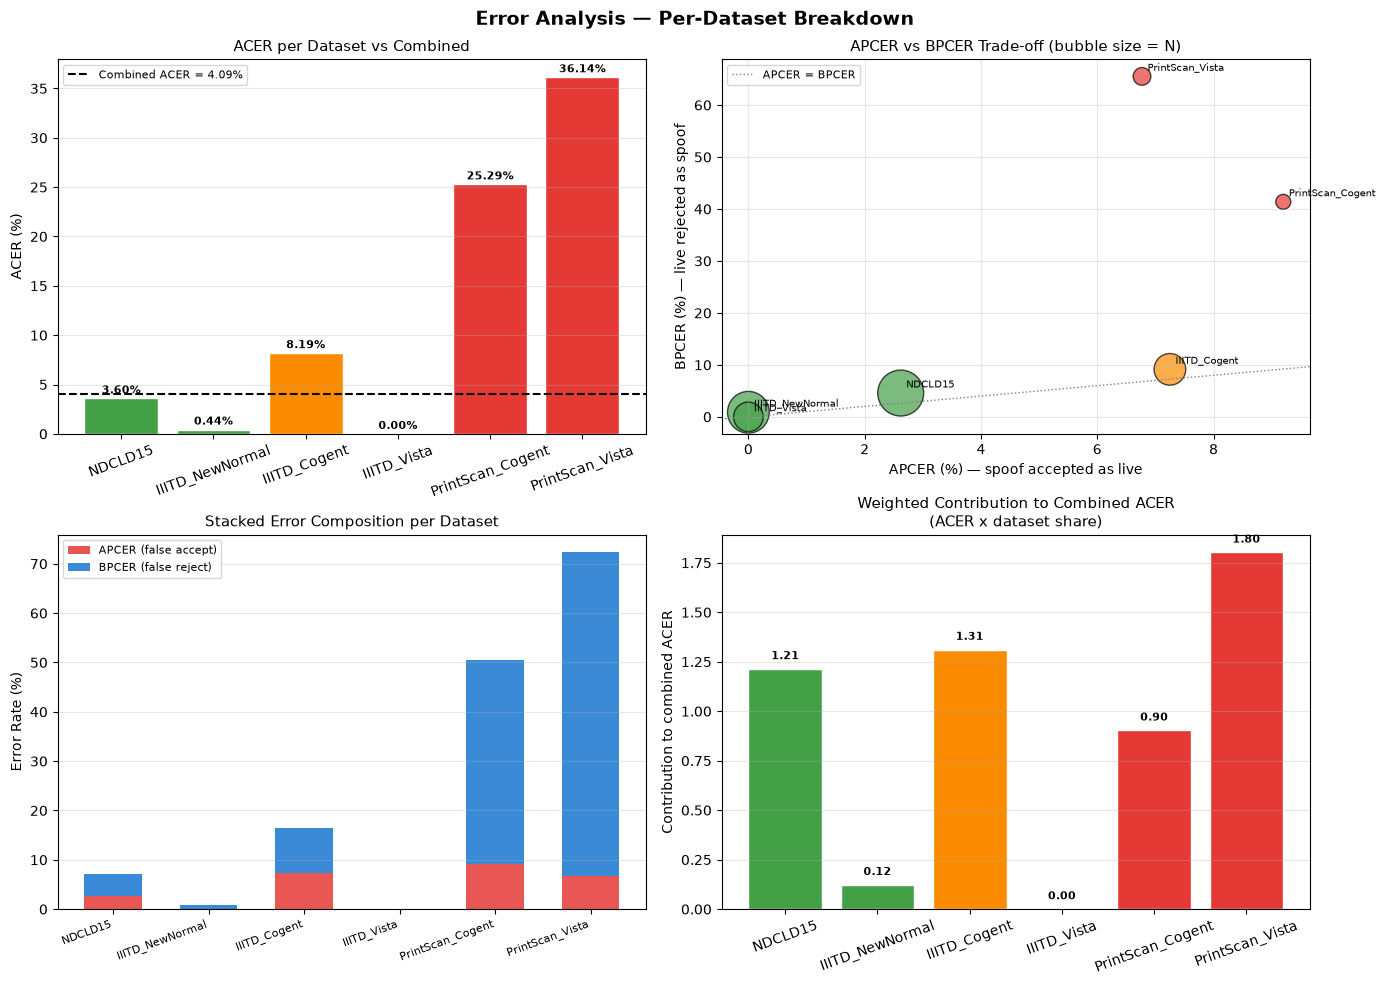

Saved → outputs/reports/error_analysis_graphs.png

Biggest contributor to combined ACER: PrintScan_Vista (ACER=36.14%, contributes 1.80 points of the combined 4.09% ACER)


In [15]:
# ── CELL: Error Analysis Graphs ──────────────────────────────────
# Four diagnostic plots, all built from df_per (per-dataset table)
# and the combined metrics (m, all_labels, all_preds) already computed
# in Sections 7-10 above. No retraining, no new evaluation needed.

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Error Analysis — Per-Dataset Breakdown', fontsize=14, fontweight='bold')

# ── Plot 1: ACER per dataset vs combined ACER reference line ─────
ax = axes[0][0]
colors = ['#43A047' if v < 5 else '#FB8C00' if v < 15 else '#E53935'
          for v in df_per['ACER (%)']]
bars = ax.bar(df_per['Dataset'], df_per['ACER (%)'], color=colors, edgecolor='white')
for bar, v in zip(bars, df_per['ACER (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5, f'{v:.2f}%',
            ha='center', fontsize=8, fontweight='bold')
ax.axhline(m['ACER']*100, color='black', linestyle='--', lw=1.5,
           label=f'Combined ACER = {m["ACER"]*100:.2f}%')
ax.set_title('ACER per Dataset vs Combined', fontsize=11)
ax.set_ylabel('ACER (%)')
ax.tick_params(axis='x', rotation=20)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# ── Plot 2: APCER vs BPCER scatter, per dataset ───────────────────
ax = axes[0][1]
ax.scatter(df_per['APCER (%)'], df_per['BPCER (%)'],
           s=df_per['N'], c=colors, alpha=0.7, edgecolor='black')
for _, row in df_per.iterrows():
    ax.annotate(row['Dataset'], (row['APCER (%)'], row['BPCER (%)']),
                fontsize=7, xytext=(4, 4), textcoords='offset points')
ax.axline((0,0), slope=1, color='gray', linestyle=':', lw=1, label='APCER = BPCER')
ax.set_title('APCER vs BPCER Trade-off (bubble size = N)', fontsize=11)
ax.set_xlabel('APCER (%) — spoof accepted as live')
ax.set_ylabel('BPCER (%) — live rejected as spoof')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# ── Plot 3: Misclassification breakdown (stacked) per dataset ────
ax = axes[1][0]
fn_rate = df_per['APCER (%)']  # false-accept proxy (spoof->live)
fp_rate = df_per['BPCER (%)']  # false-reject proxy (live->spoof)
x = np.arange(len(df_per))
w = 0.6
ax.bar(x, fn_rate, w, label='APCER (false accept)', color='#E53935', alpha=0.85)
ax.bar(x, fp_rate, w, bottom=fn_rate, label='BPCER (false reject)', color='#1976D2', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(df_per['Dataset'], rotation=20, ha='right', fontsize=8)
ax.set_title('Stacked Error Composition per Dataset', fontsize=11)
ax.set_ylabel('Error Rate (%)')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# ── Plot 4: Sample-size-weighted error contribution ───────────────
ax = axes[1][1]
df_per['error_contribution'] = df_per['ACER (%)'] * df_per['N'] / df_per['N'].sum()
bars = ax.bar(df_per['Dataset'], df_per['error_contribution'], color=colors, edgecolor='white')
for bar, v in zip(bars, df_per['error_contribution']):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.05, f'{v:.2f}',
            ha='center', fontsize=8, fontweight='bold')
ax.set_title('Weighted Contribution to Combined ACER\n(ACER x dataset share)', fontsize=11)
ax.set_ylabel('Contribution to combined ACER')
ax.tick_params(axis='x', rotation=20)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'reports', 'error_analysis_graphs.png'),
            dpi=130, bbox_inches='tight')
plt.show()
print('Saved → outputs/reports/error_analysis_graphs.png')

# ── Print the single biggest contributor explicitly ───────────────
worst_contributor = df_per.loc[df_per['error_contribution'].idxmax()]
print(f"\nBiggest contributor to combined ACER: {worst_contributor['Dataset']} "
      f"(ACER={worst_contributor['ACER (%)']:.2f}%, contributes "
      f"{worst_contributor['error_contribution']:.2f} points of the combined {m['ACER']*100:.2f}% ACER)")

## 12. Disaggregated Structural Error Plots

The per-dataset bar charts in Section 11 show WHICH dataset has high error,
but not WHY. This section disaggregates the same predictions along three
structural axes that matter for presentation attack detection specifically:

1. **By attack type** (contact lens vs print attack) — pooling NDCLD15 +
   IIITD as "contact lens" and PrintScan as "print attack" tests whether
   the error is attack-type-specific or sensor-specific.
2. **By sensor pair** (Cogent vs Vista) — the same attack type captured on
   two different sensors, isolating whether Cogent or Vista hardware itself
   is the harder case.
3. **By decision threshold** — APCER and BPCER both depend on where the
   0.5 cutoff sits; this shows how each dataset's error trades off as the
   threshold moves, rather than reporting only the single fixed-threshold
   numbers already computed above.

All three reuse `all_labels`, `all_probs`, and `test_df_full` already
computed in Sections 8-10 - no retraining or new inference is performed.

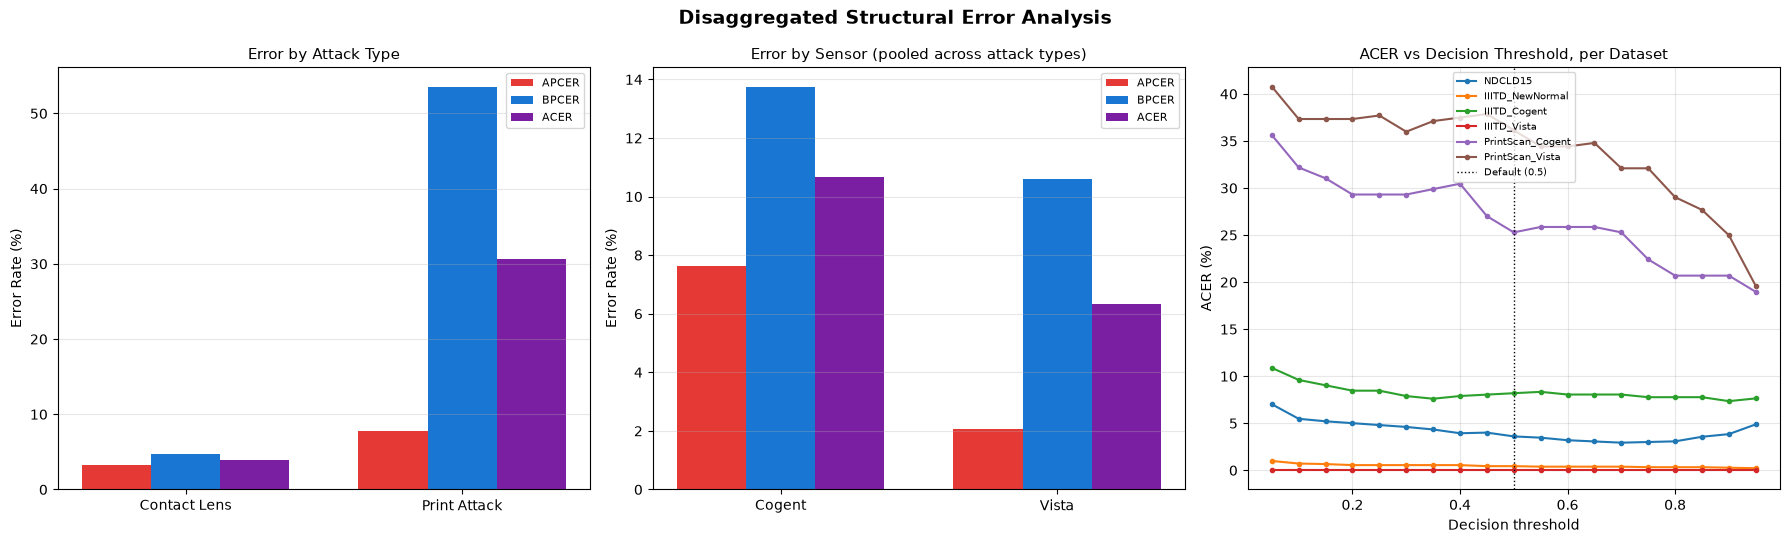

Saved → outputs/reports/disaggregated_structural_errors.png

===== ERROR BY ATTACK TYPE =====
 Attack Type    N  APCER  BPCER  ACER
Contact Lens 2067   3.21   4.74  3.98
Print Attack  278   7.73  53.45 30.59

===== ERROR BY SENSOR =====
Sensor   N  APCER  BPCER  ACER
Cogent 636   7.64  13.73 10.68
 Vista 614   2.07  10.61  6.34


In [22]:
# ── CELL: Disaggregated Structural Error Plots ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.suptitle('Disaggregated Structural Error Analysis', fontsize=14, fontweight='bold')

ATTACK_TYPE_MAP = {
    'NDCLD15':          'Contact Lens',
    'IIITD_Cogent':      'Contact Lens',
    'IIITD_Vista':       'Contact Lens',
    'PrintScan_Cogent':  'Print Attack',
    'PrintScan_Vista':   'Print Attack',
}
attack_rows = []
for attack_type in ['Contact Lens', 'Print Attack']:
    ds_names = [k for k, v in ATTACK_TYPE_MAP.items() if v == attack_type]
    sub = test_df_full[test_df_full['dataset'].isin(ds_names)].reset_index(drop=True)
    if len(sub) == 0:
        continue
    ds_obj = IrisDataset.__new__(IrisDataset)
    ds_obj.df = sub
    ds_obj.transform = val_transform
    ds_obj.norm_stats = norm_stats
    loader = DataLoader(ds_obj, BATCH_SIZE, shuffle=False)
    preds_t, labels_t = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            global_logits, _ = model(imgs.to(DEVICE))
            preds_t.extend(global_logits.argmax(1).cpu().numpy())
            labels_t.extend(lbls.numpy())
    mi = iso_metrics(np.array(labels_t), np.array(preds_t))
    attack_rows.append({'Attack Type': attack_type, 'N': len(sub),
                         'APCER': mi['APCER']*100, 'BPCER': mi['BPCER']*100,
                         'ACER': mi['ACER']*100})

df_attack = pd.DataFrame(attack_rows)
x = np.arange(len(df_attack)); w = 0.25
axes[0].bar(x-w, df_attack['APCER'], w, label='APCER', color='#E53935')
axes[0].bar(x,   df_attack['BPCER'], w, label='BPCER', color='#1976D2')
axes[0].bar(x+w, df_attack['ACER'],  w, label='ACER',  color='#7B1FA2')
axes[0].set_xticks(x); axes[0].set_xticklabels(df_attack['Attack Type'])
axes[0].set_title('Error by Attack Type', fontsize=11)
axes[0].set_ylabel('Error Rate (%)')
axes[0].legend(fontsize=8); axes[0].grid(axis='y', alpha=0.3)

SENSOR_MAP = {
    'IIITD_Cogent':     'Cogent',
    'PrintScan_Cogent':  'Cogent',
    'IIITD_Vista':       'Vista',
    'PrintScan_Vista':   'Vista',
}
sensor_rows = []
for sensor in ['Cogent', 'Vista']:
    ds_names = [k for k, v in SENSOR_MAP.items() if v == sensor]
    sub = test_df_full[test_df_full['dataset'].isin(ds_names)].reset_index(drop=True)
    if len(sub) == 0:
        continue
    ds_obj = IrisDataset.__new__(IrisDataset)
    ds_obj.df = sub
    ds_obj.transform = val_transform
    ds_obj.norm_stats = norm_stats
    loader = DataLoader(ds_obj, BATCH_SIZE, shuffle=False)
    preds_s, labels_s = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            global_logits, _ = model(imgs.to(DEVICE))
            preds_s.extend(global_logits.argmax(1).cpu().numpy())
            labels_s.extend(lbls.numpy())
    mi = iso_metrics(np.array(labels_s), np.array(preds_s))
    sensor_rows.append({'Sensor': sensor, 'N': len(sub),
                         'APCER': mi['APCER']*100, 'BPCER': mi['BPCER']*100,
                         'ACER': mi['ACER']*100})

df_sensor = pd.DataFrame(sensor_rows)
x = np.arange(len(df_sensor))
axes[1].bar(x-w, df_sensor['APCER'], w, label='APCER', color='#E53935')
axes[1].bar(x,   df_sensor['BPCER'], w, label='BPCER', color='#1976D2')
axes[1].bar(x+w, df_sensor['ACER'],  w, label='ACER',  color='#7B1FA2')
axes[1].set_xticks(x); axes[1].set_xticklabels(df_sensor['Sensor'])
axes[1].set_title('Error by Sensor (pooled across attack types)', fontsize=11)
axes[1].set_ylabel('Error Rate (%)')
axes[1].legend(fontsize=8); axes[1].grid(axis='y', alpha=0.3)

thresholds = np.arange(0.05, 0.96, 0.05)
for ds_name in df_per['Dataset']:
    sub = test_df_full[test_df_full['dataset'] == ds_name].reset_index(drop=True)
    if len(sub) == 0:
        continue
    ds_obj = IrisDataset.__new__(IrisDataset)
    ds_obj.df = sub
    ds_obj.transform = val_transform
    ds_obj.norm_stats = norm_stats
    loader = DataLoader(ds_obj, BATCH_SIZE, shuffle=False)
    probs_d, labels_d = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            global_logits, _ = model(imgs.to(DEVICE))
            probs_d.extend(torch.softmax(global_logits, dim=1)[:, 1].cpu().numpy())
            labels_d.extend(lbls.numpy())
    probs_d  = np.array(probs_d)
    labels_d = np.array(labels_d)

    acer_curve = []
    for t in thresholds:
        preds_t = (probs_d >= t).astype(int)
        mi = iso_metrics(labels_d, preds_t)
        acer_curve.append(mi['ACER'] * 100)
    axes[2].plot(thresholds, acer_curve, marker='o', ms=3, label=ds_name, lw=1.5)

axes[2].axvline(0.5, color='black', linestyle=':', lw=1, label='Default (0.5)')
axes[2].set_title('ACER vs Decision Threshold, per Dataset', fontsize=11)
axes[2].set_xlabel('Decision threshold')
axes[2].set_ylabel('ACER (%)')
axes[2].legend(fontsize=7, loc='upper center')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'reports', 'disaggregated_structural_errors.png'),
            dpi=130, bbox_inches='tight')
plt.show()
print('Saved → outputs/reports/disaggregated_structural_errors.png')

print('\n===== ERROR BY ATTACK TYPE =====')
print(df_attack.round(2).to_string(index=False))
print('\n===== ERROR BY SENSOR =====')
print(df_sensor.round(2).to_string(index=False))

## 13. Per-Dataset vs Combined Summary Chart

A direct visual comparison of ACER per dataset against the single combined
(pooled) ACER reported in Section 9, so the gap between "looks fine on
average" and "fails badly on one sensor" - the exact problem this revision
targets - is visible in one chart rather than only in the printed table above.


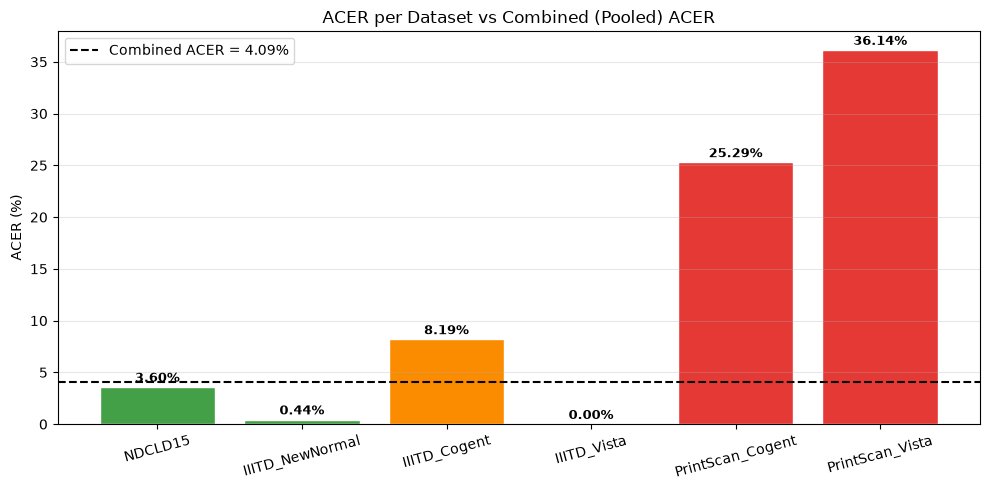

Saved → outputs/reports/acer_per_dataset_vs_combined.png


In [17]:
# ---------------------------------------------------------------------------
# Bar chart of per-dataset ACER with the combined/overall ACER drawn as a
# reference line, so any remaining per-dataset outlier is immediately visible
# even if the combined number looks acceptable.
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#43A047' if v < 5 else '#FB8C00' if v < 15 else '#E53935'
          for v in df_per['ACER (%)']]
bars = ax.bar(df_per['Dataset'], df_per['ACER (%)'], color=colors, edgecolor='white')
for bar, v in zip(bars, df_per['ACER (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5, f'{v:.2f}%',
            ha='center', fontsize=9, fontweight='bold')

ax.axhline(m['ACER']*100, color='black', linestyle='--', lw=1.5,
           label=f'Combined ACER = {m["ACER"]*100:.2f}%')
ax.set(title='ACER per Dataset vs Combined (Pooled) ACER',
       ylabel='ACER (%)')
ax.tick_params(axis='x', rotation=15)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'reports', 'acer_per_dataset_vs_combined.png'),
            dpi=120, bbox_inches='tight')
plt.show()
print('Saved \u2192 outputs/reports/acer_per_dataset_vs_combined.png')


## 14. Done - Summary


In [19]:
# ---------------------------------------------------------------------------
# Final summary, including a direct before/after note for the PrintScan
# subsets that motivated this revision.
# ---------------------------------------------------------------------------

print('\n=== COMBINED (POOLED) RESULTS ===')
print(f'  Accuracy : {acc:.2f}%')
print(f'  APCER    : {m["APCER"]*100:.2f}%')
print(f'  BPCER    : {m["BPCER"]*100:.2f}%')
print(f'  ACER     : {m["ACER"]*100:.2f}%')
print(f'  AUC      : {roc_auc:.4f}')

print('\n=== PER-DATASET RESULTS ===')
print(df_per.to_string(index=False))

print('\n=== WHAT CHANGED IN THIS REVISION ===')
print('  1. Per-dataset normalization (dataset_norm_stats.json) replaces fixed ImageNet stats')
print('  2. WeightedRandomSampler boosts PrintScan_Cogent/Vista to 3.0x their raw share')
print('  3. CLASS_WEIGHTS now passed into both the main loss and the pixel-wise loss')
print('  4. Pixel-wise Binary Supervision head added (7x7 patch-level supervision)')

print(f'\nBest model saved \u2192 {BEST_MODEL_PATH}')




=== COMBINED (POOLED) RESULTS ===
  Accuracy : 95.91%
  APCER    : 3.83%
  BPCER    : 4.34%
  ACER     : 4.09%
  AUC      : 0.9939

=== PER-DATASET RESULTS ===
         Dataset    N  Acc (%)  APCER (%)  BPCER (%)  ACER (%)  error_contribution
         NDCLD15 1095    96.71       2.62       4.58      3.60            1.213296
 IIITD_NewNormal  904    99.12       0.00       0.88      0.44            0.122425
    IIITD_Cogent  520    92.12       7.25       9.14      8.19            1.310803
     IIITD_Vista  452   100.00       0.00       0.00      0.00            0.000000
PrintScan_Cogent  116    82.76       9.20      41.38     25.29            0.902936
 PrintScan_Vista  162    82.72       6.77      65.52     36.14            1.801994

=== WHAT CHANGED IN THIS REVISION ===
  1. Per-dataset normalization (dataset_norm_stats.json) replaces fixed ImageNet stats
  2. WeightedRandomSampler boosts PrintScan_Cogent/Vista to 3.0x their raw share
  3. CLASS_WEIGHTS now passed into both the main lo